In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize as opt

In [226]:
data = pd.read_csv("data/velocities.csv")

In [228]:
print(data.head())
# Renaming the datas with their 

   Trail  height(m)  height_err(m)  velocity(m/s)  velocity_err(m/s)
0      1        0.4            0.1            2.6                0.6
1      2        0.8            0.1            4.1                0.4
2      3        1.4            0.1            5.0                0.3
3      4        2.0            0.1            6.2                0.3
4      5        2.6            0.1            6.7                0.4


In [230]:
average_velocity = np.mean(data.iloc[:, 3])
print(f"The average velocity is {average_velocity:.2f} +/- {np.mean(data['velocity_err(m/s)']):.2f} m/s")

The average velocity is 5.87 +/- 0.34 m/s


In [234]:
data['veloctiy_squared(m/s)**2'] = data['velocity(m/s)']**2
data['veloctiy_squared(m/s)**2']

0     6.76
1    16.81
2    25.00
3    38.44
4    44.89
5    62.41
6    73.96
Name: veloctiy_squared(m/s)**2, dtype: float64

In [236]:
data.head()

,Trail,height(m),height_err(m),velocity(m/s),velocity_err(m/s),veloctiy_squared(m/s)**2
0,1,0.4,0.1,2.6,0.6,6.76
1,2,0.8,0.1,4.1,0.4,16.81
2,3,1.4,0.1,5.0,0.3,25.00
3,4,2.0,0.1,6.2,0.3,38.44
4,5,2.6,0.1,6.7,0.4,44.89


In [242]:
data['velocity_squared_err(m/s)**2'] = 2 * data['velocity(m/s)'] * data['velocity_err(m/s)']

In [246]:
data.head()

,Trail,height(m),height_err(m),velocity(m/s),velocity_err(m/s),veloctiy_squared(m/s)**2,velocity_squared_err(m/s)**2
0,1,0.4,0.1,2.6,0.6,6.76,3.12
1,2,0.8,0.1,4.1,0.4,16.81,3.28
2,3,1.4,0.1,5.0,0.3,25.00,3.00
3,4,2.0,0.1,6.2,0.3,38.44,3.72
4,5,2.6,0.1,6.7,0.4,44.89,5.36


In [252]:
print(data.columns.values)

['Trail' 'height(m)' 'height_err(m)' 'velocity(m/s)' 'velocity_err(m/s)'
 'veloctiy_squared(m/s)**2' 'velocity_squared_err(m/s)**2']


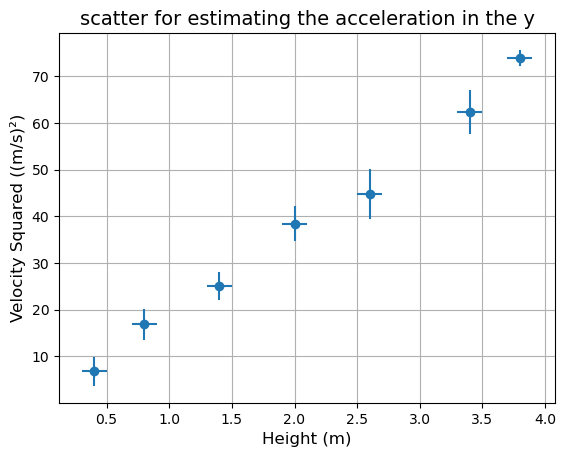

In [258]:
x = data['height(m)']
y = data['veloctiy_squared(m/s)**2']
plt.errorbar(x, y, yerr=data['velocity_squared_err(m/s)**2'], xerr=data['height_err(m)'],fmt='o')

plt.title("scatter for estimating the acceleration in the y", fontsize=14)
plt.xlabel("Height (m)", fontsize=12)
plt.ylabel("Velocity Squared ((m/s)^2)", fontsize=12)
plt.grid(True)
plt.show()

In [260]:
def linear_model(x, A, B):
    return (A * x) + B

In [264]:

par, cov = opt.curve_fit(linear_model,          # this function returns the paremetrs that best fit our linear model ( so the parameters of A and B) the first parameter "my_line_model" is our function model and its first parameter should be a list of the dependent variables
                       data["height(m)"],  # this is the dependent variable (distance in this case)
                       data["veloctiy_squared(m/s)**2"],       # this is a list of the independent variabels (time in this case)
                       sigma=data["velocity_squared_err(m/s)**2"],       # this is a list that tells the amount of uncertainties for each data instance
                       absolute_sigma = True)

In [266]:
print(par)

[19.53580107 -0.98268698]


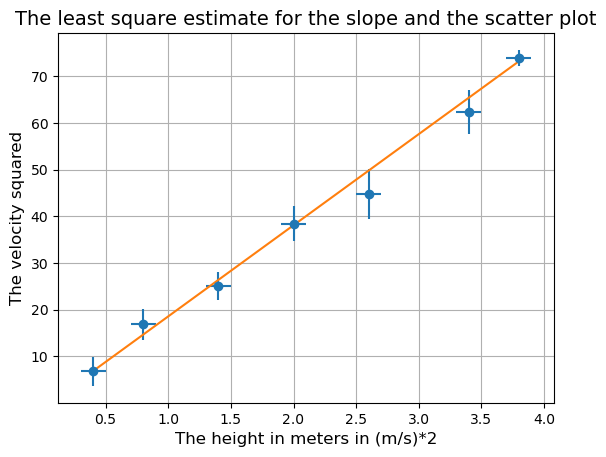

In [274]:
x = data['height(m)']
y = data['veloctiy_squared(m/s)**2']
plt.errorbar(x, y, yerr=data['velocity_squared_err(m/s)**2'], xerr=data['height_err(m)'],fmt='o')

plt.title("The least square estimate for the slope and the scatter plot", fontsize=14)
plt.xlabel("Height (m)", fontsize=12)
plt.ylabel("Velocity Squared ((m/s)^2)", fontsize=12)
plt.grid(True)
x = np.linspace(min(data['height(m)']), max(data['height(m)']), 1000)
plt.xlabel("The height in meters in (m/s)*2")
plt.ylabel("The velocity squared")
plt.plot(x, x * par[0] + par[1])

In [276]:
std_err = [np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])]

In [278]:
print(f"2 * gravity = {par[0]} +/- {std_err[0]}")
print(f"Gravity = {par[0] / 2:.2f} +/- {std_err[0]/2:.2f}")

2 * gravity = 19.535801065596154 +/- 0.8223302841524878
Gravity = 9.77 +/- 0.41


In [280]:
print("My measured density: %2.1f +/- %2.1f m/(s**2)" % (par[0]/2, std_err[0]/2))

My measured density: 9.8 +/- 0.4 m/(s**2)
